In [25]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_svmlight_file
from scipy.stats import levy_stable


In [ ]:
# 1. SETUP & DATA LOADING
# Using A9a dataset (Binary Classification)
# You can download 'a9a' from LIBSVM website or use a local path
def get_data():
    # For a quick start, let's generate a synthetic sharp dataset if a9a isn't local
    # But for your project, replace this with: load_svmlight_file('a9a.txt')
    # x = torch.randn(2000, 123) 
    # y = torch.randint(0, 2, (2000,)).float()
    # X_train, y_train = load_svmlight_file("a9a")
    # X_test, y_test = load_svmlight_file("a9a.t")

    X_train, y_train = load_svmlight_file("a9a.txt", n_features=123)
    X_test, y_test = load_svmlight_file("a9a.t", n_features=123)

    # Convert to Dense Tensors
    X_train = torch.from_numpy(X_train.toarray()).float()
    y_train = torch.from_numpy(y_train).float()
    X_test = torch.from_numpy(X_test.toarray()).float()
    y_test = torch.from_numpy(y_test).float()

    # Crucial: a9a labels are -1 and 1. Change to 0 and 1 for BCE Loss.
    y_train[y_train == -1] = 0
    y_test[y_test == -1] = 0

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = get_data()


In [ ]:
# 2. DEFINING THE MODEL & NON-CONVEX LOSS
class NonConvexLogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(NonConvexLogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1, bias=False)
        
    def forward(self, X_train):
        return self.linear(X_train).squeeze()

def non_convex_regularizer(model, lam=0.1, alpha=1.0):
    reg = 0
    for param in model.parameters():
        # Geman-McClure: sum( (lam * w^2) / (1 + alpha * w^2) )
        reg += torch.sum((lam * param**2) / (1 + alpha * param**2))
    return reg



In [28]:
# 3. NOISE GENERATION (Lévy / Heavy-Tailed)
def add_heavy_tailed_noise(grad, alpha_levy=1.5, scale=0.01):
    """
    alpha_levy: 2.0 is Gaussian, 1.0 is Cauchy (Heavier).
    The paper suggests alpha < 2 captures the 'spikes'.
    """
    noise = levy_stable.rvs(alpha_levy, 0, scale=scale, size=grad.shape)
    return grad + torch.from_numpy(noise).float()



In [71]:
# 4. TRAINING LOOP
def run_experiment(opt_type='sgd', alpha_levy=1.5, lr=0.01, epochs=100):
    model = NonConvexLogisticRegression(123)
    criterion = nn.BCEWithLogitsLoss()
    losses = []
    
    for epoch in range(epochs):
        # Full batch gradient for stability control, then add synthetic noise
        outputs = model(X_train)

        #regularizer
        loss_val = criterion(outputs, y_train) + non_convex_regularizer(model)

        #without regularizer
        # loss_val = criterion(outputs, y_train)
    
        
        model.zero_grad()
        loss_val.backward()
        
        with torch.no_grad():
            for param in model.parameters():
                # Inject Heavy-Tailed Noise into the gradient
                noisy_grad = add_heavy_tailed_noise(param.grad, alpha_levy)
                
                if opt_type == 'sgd':
                    param -= lr * noisy_grad
                elif opt_type == 'signsgd':
                    # DSignSGD Step: sign(grad + noise)
                    param -= lr * torch.sign(noisy_grad)
        
        losses.append(loss_val.item())
    return losses, model



In [ ]:
# 5. RUNNING THE COMPARISON

# alpha = 1.3, lr = 0.01
print("Running Experiments...")
history_sgd, model_sgd = run_experiment(opt_type='sgd', alpha_levy=1.3, lr=0.01)
history_signsgd, model_signsgd = run_experiment(opt_type='signsgd', alpha_levy=1.3, lr=0.01)


Running Experiments...


In [77]:
# alpha = 1.3, lr = 0.01 (signsgd), 1 (sgd)
print("Running Experiments...")
history_sgd, model_sgd = run_experiment(opt_type='sgd', alpha_levy=1.3, lr=0.01)
history_signsgd, model_signsgd = run_experiment(opt_type='signsgd', alpha_levy=1.3, lr=0.01)


Running Experiments...


In [48]:
# alpha = 2.0, lr = 0.01

print("Running Experiments...")
history_sgd, model_sgd = run_experiment(opt_type='sgd', alpha_levy=2, lr=0.01)
history_signsgd, model_signsgd = run_experiment(opt_type='signsgd', alpha_levy=2, lr=0.01)

Running Experiments...


In [ ]:
# alpha = 2.0, lr = 0.0001

print("Running Experiments...")
history_sgd, model_sgd = run_experiment(opt_type='sgd', alpha_levy=2, lr=0.0001)
history_signsgd, model_signsgd = run_experiment(opt_type='signsgd', alpha_levy=2, lr=0.0001)

Running Experiments...


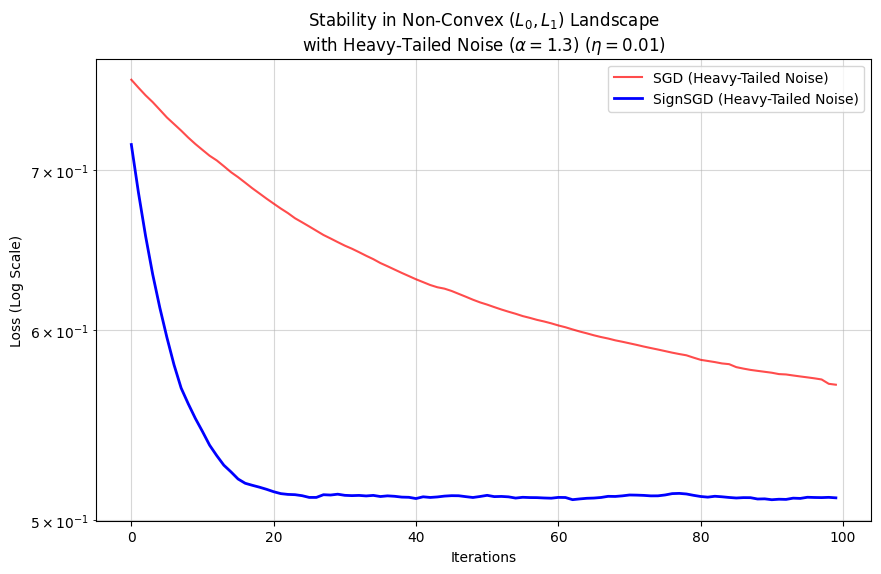

In [78]:
# 6. PLOTTING RESULTS
plt.figure(figsize=(10, 6))
plt.plot(history_sgd, label='SGD (Heavy-Tailed Noise)', color='red', alpha=0.7)
plt.plot(history_signsgd, label='SignSGD (Heavy-Tailed Noise)', color='blue', lw=2)
plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Loss (Log Scale)')
plt.title('Stability in Non-Convex $(L_0, L_1)$ Landscape\nwith Heavy-Tailed Noise ($\\alpha=1.3$) ($\\eta=0.01$)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_1d_landscape(model, X, y, optimal_weights, lam=0.1):

    # 1. SAVE the real weights so we don't break the model
    original_state = {name: param.clone() for name, param in model.named_parameters()}
    
    start_weights = torch.randn_like(optimal_weights) * 0.5
    alphas = np.linspace(-0.5, 1.5, 50) 
    losses = []

    # # 1. Create a random starting direction
    # start_weights = torch.randn_like(optimal_weights) * 0.5
    
    # # 2. Create the linear path (alphas)
    # alphas = np.linspace(-0.5, 1.5, 50) 
    # losses = []

    # print("Mapping the landscape... please wait.")
    
    for a in alphas:
        # Interpolate between random point and trained optimal point
        # W_current = (1-a)*W_start + a*W_optimal
        current_w = (1 - a) * start_weights + a * optimal_weights
        
        with torch.no_grad():
            # Overwrite temporarily to calculate loss
            for name, param in model.named_parameters():
                param.copy_(current_w)
            
            out = model(X)
            loss = torch.nn.BCEWithLogitsLoss()(out, y) + non_convex_regularizer(model, lam=lam)
            losses.append(loss.item())

        # Load these weights into the model
        # with torch.no_grad():
        #     state_dict = model.state_dict()
        #     for name, param in model.named_parameters():
        #         state_dict[name].copy_(current_w)
            
        #     # Forward pass
        #     out = model(X)
        #     # Loss = Data Loss + Non-Convex Regularizer
        #     loss = torch.nn.BCEWithLogitsLoss()(out, y) + non_convex_regularizer(model, lam=lam)
        #     losses.append(loss.item())

    with torch.no_grad():
        for name, param in model.named_parameters():
            param.copy_(original_state[name])
    
    # 3. Actually Plot it
    plt.figure(figsize=(8, 5))
    plt.plot(alphas, losses, color='teal', lw=2)
    plt.axvline(x=1.0, color='red', linestyle='--', label='Trained Weights')
    plt.axvline(x=0.0, color='gray', linestyle='--', label='Random Start')
    
    plt.title("A Slice of the Landscape")
    plt.xlabel("Step along the path (Alpha)")
    plt.ylabel("Total Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show() # <--- This makes the plot appear!

# To run it, make sure you have 'model' and 'X_train', 'y_train' defined
# and that 'optimal_weights' is model.linear.weight.data (or similar)

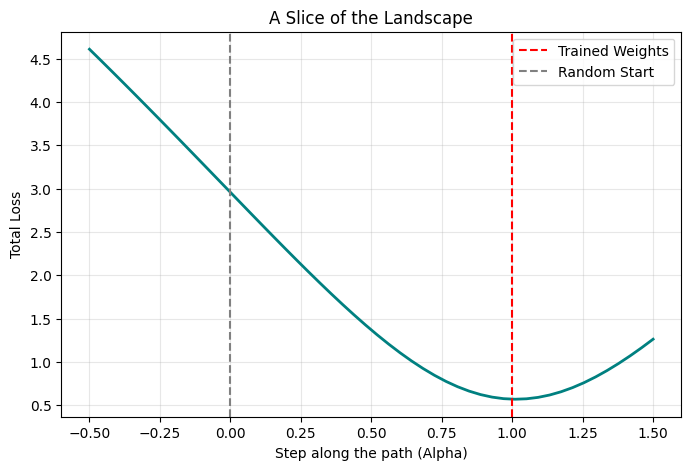

In [80]:
opt_w = list(model_sgd.parameters())[0].data.clone()
plot_1d_landscape(model_sgd, X_train, y_train, opt_w, lam=0.1)

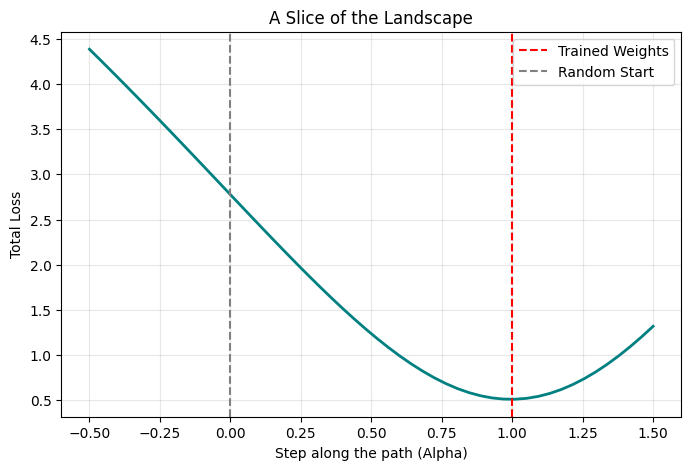

In [81]:
opt_w = list(model_signsgd.parameters())[0].data.clone()
plot_1d_landscape(model_signsgd, X_train, y_train, opt_w, lam=0.1)